# Imports

In [1]:
# imports
import sys
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import yaml
from heap import coincidences, correct_after_meridian_flip, image_cleaning, make_pedestals, parameterize, pre_cleaning
from datetime import datetime
from tqdm import tqdm


In [2]:
# source: https://joseph-long.com/writing/colorbars/
def colorbar(mappable, label=None):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    if label is not None:
        cbar.set_label(label)
    plt.sca(last_axes)
    return cbar

# Analyze Data

In [3]:
# Configuration: telescope map + data product tag come from the same nextday_config.yaml
# that run_nextday_pipeline.py uses, so there's one source of truth for module -> telescope name
# and rate_cut.
NEXTDAY_CONFIG = "/home/nkorzoun/research/PANOSETI/High-Energy-Analysis-Pipeline.worktrees/python-pipeline--nextday/NextDay/nextday_config.yaml"
with open(NEXTDAY_CONFIG) as f:
    nextday_config = yaml.safe_load(f)

module_names = nextday_config["telescopes"]  # e.g. {"module_250": {"name": "Heli", "rate_cut": 100}, ...}
DATA_PRODUCT = "dp_ph1024"

data_dir = Path("/home/nkorzoun/research/PANOSETI/High-Energy-Analysis-Pipeline.worktrees/python-pipeline--nextday//test_data/20260709/obs_Palomar.start_2026-07-09T07:22:57Z.runtype_obs-test.pffd")
# data_dir = Path("/home/nkorzoun/research/PANOSETI/High-Energy-Analysis-Pipeline.worktrees/python-pipeline--nextday/test_data/20260618/obs_Palomar.start_2026-06-18T09:07:27Z.runtype_obs-test.pffd")
hk_file = data_dir / "hk.pff"


def load_telescope_events(module_pattern, data_dir, hk_file, mount_key, rate_cut):
    """Load + clean one telescope's events via coincidences.load_telescope_tv (the same
    loader run_nextday_pipeline.py uses: read_pff -> cut_pkt_loss_old -> spike_cut), then apply
    the meridian-flip cut if this telescope has mount tracking data in hk.pff.

    mount_key: the hk.pff key holding this telescope's mount tracking data (e.g. "MOUNT_WINTER").
    Fixed alt-az modules have no such table in hk.pff, so the meridian-flip cut is skipped for them.
    rate_cut: spike_cut's trigger-rate threshold (Hz), see nextday_config.yaml's telescopes section.
    """
    try:
        data, timestamps = coincidences.load_telescope_tv(module_pattern, data_dir, rate_cut, plotting=False)
    except RuntimeError as e:
        print(f"  Skipping: {e}")
        return None, None

    hk = pre_cleaning.read_pff_hk(str(hk_file))
    if mount_key in hk and "tracking" in hk[mount_key]:
        track = np.asarray(hk[mount_key]["tracking"])
        if np.any(track == "False"):
            try:
                data, timestamps, _, _ = correct_after_meridian_flip.divide_data_meridian_flip(data, timestamps, hk, time_after=60, plotting=False, path=None)
                data, timestamps = correct_after_meridian_flip.rotate_after_flip(data, timestamps)
            except (IndexError, ValueError) as e:
                print(f"  Warning: meridian flip cut failed ({e}), keeping data")
        else:
            print(f"  No meridian flip detected")
    else:
        print(f"  No tracking data available for {mount_key}, skipping meridian flip cut")

    if len(data) == 0:
        print(f"  Skipping: empty after all cuts")
        return None, None

    print(f"  Total dataset: {data.shape}")
    return data, timestamps


In [4]:
def compute_pedestals(pff_dataset, pff_times, time_window=600, max_gap=300):
    """Create pedestals from 10-minute chunks, respecting observing segments (a gap >max_gap starts a new sequence)."""
    pedestals_per_chunk = []
    pedvars_per_chunk = []
    chunk_info = []

    # Sort by time
    sort_idx = np.argsort(pff_times)
    sorted_times = pff_times[sort_idx]
    sorted_data = pff_dataset[sort_idx]

    # Find gaps in the data (new nights, meridian flips, weather cuts, etc.)
    time_diffs = np.diff(sorted_times)
    gap_indices = np.where(time_diffs > max_gap)[0]

    # Split into continuous segments
    segment_starts = [0] + (gap_indices + 1).tolist()
    segment_ends = gap_indices.tolist() + [len(sorted_times)]

    print(f"  Found {len(segment_starts)} continuous observing segments")

    for seg_start, seg_end in zip(segment_starts, segment_ends):
        seg_times = sorted_times[seg_start:seg_end]
        seg_data = sorted_data[seg_start:seg_end]

        if len(seg_data) < 100:
            print(f"    Skipping short segment with only {len(seg_data)} frames")
            continue

        seg_date = datetime.fromtimestamp(seg_times[0]).strftime('%Y%m%d')
        print(f"    Processing segment from {seg_date}, {len(seg_data)} frames")

        start_time = seg_times[0]
        end_time = seg_times[-1]

        current_time = start_time
        while current_time < end_time:
            mask = (seg_times >= current_time) & (seg_times < current_time + time_window)
            chunk_data = seg_data[mask]
            chunk_indices = np.where(mask)[0] + seg_start  # Global indices

            if len(chunk_data) > 100:  # Need enough frames to make a good pedestal
                ped, ped_var = make_pedestals.calculate_pedestal_and_pedvar(chunk_data, nsig=5.0, fit_gaussian=True)
                pedestals_per_chunk.append(ped)
                pedvars_per_chunk.append(ped_var)
                chunk_info.append({
                    'indices': chunk_indices,
                    'date': seg_date,
                    'n_frames': len(chunk_data)
                })
                print(f"      Created pedestal at {datetime.fromtimestamp(current_time).strftime('%H:%M:%S')} using {len(chunk_data)} frames")
            else:
                print(f"      Skipping window at {datetime.fromtimestamp(current_time).strftime('%H:%M:%S')}, only {len(chunk_data)} frames")

            current_time += time_window

    print(f"  Created {len(pedestals_per_chunk)} pedestals")

    pedestals = np.zeros((len(pff_dataset), 1024), dtype=np.float32)
    pedestal_variances = np.zeros((len(pff_dataset), 1024), dtype=np.float32)

    for ped, ped_var, info in zip(pedestals_per_chunk, pedvars_per_chunk, chunk_info):
        for idx in info['indices']:
            pedestals[sort_idx[idx]] = ped
            pedestal_variances[sort_idx[idx]] = ped_var

    print(f"  Assigned pedestals to {len(pff_dataset)} frames")
    return pedestals, pedestal_variances


In [5]:
def clean_and_parameterize(pff_dataset, pedestals, pedestal_variances, pff_times):
    all_params = []
    pff_images_cleaned = []

    for i, (event, ped, pedvar, timestamp) in tqdm(enumerate(zip(pff_dataset, pedestals, pedestal_variances, pff_times)),
                                                     total=len(pff_dataset),
                                                     desc="Processing events"):

        ped_subtracted_event = event - ped
        cleaned_event, mask = image_cleaning.threshold_clean(
            ped_subtracted_event.reshape(32,32),
            pedvar.reshape(32,32),
            image_threshold=4,
            border_threshold=2
        )

        pff_images_cleaned.append(cleaned_event)

        # Determine x, y offsets based on date
        # date = datetime.fromtimestamp(timestamp).strftime('%Y%m%d')

        # if date in ['20251017', '20251018']:
        #     x_offset = -3.0
        #     y_offset = -1.106
        # else:
        #     x_offset = -2.0
        #     y_offset = -0.106

        # tmp = x_offset
        # x_offset = -y_offset
        # y_offset = -tmp
        params = parameterize.calc_params(cleaned_event)

        params['Event'] = i
        params['Timestamp'] = timestamp

        all_params.append(params)

    pff_images_cleaned = np.stack(pff_images_cleaned, axis=0)
    pff_data_df = pd.DataFrame(all_params)
    return pff_images_cleaned, pff_data_df


In [6]:
# convert pixels to degrees
def convert_units(df):
    df = df.copy()
    columns = ['x_c', 'y_c', 's_xx', 's_yy', 's_xy', 'length', 'width', 'miss', 'distance']
    for c in columns:
        df[c] = df[c] * 0.31
        if c in ['x_c', 'y_c']:
            df[c] = df[c] - 4.96 + 0.31
    return df


In [7]:
def postprocess_df(df):
    df = df.dropna(subset=["length", "width", "miss", "distance", "alpha"])
    df = df[df["width"] > 0]
    df = df[df.N_pix > 3]
    # remove duplicates
    df = df.drop_duplicates(subset=df.drop(["Event"], axis=1))
    return df


In [8]:
def process_pff_file(module_pattern, data_dir, hk_file, mount_key, rate_cut):
    """Run the full single-telescope pipeline: load, cut, pedestal, clean, parameterize."""
    pff_dataset, pff_times = load_telescope_events(module_pattern, data_dir, hk_file, mount_key, rate_cut)
    if pff_dataset is None or len(pff_dataset) == 0:
        return None, None, None

    pedestals, pedestal_variances = compute_pedestals(pff_dataset, pff_times)

    pff_images_cleaned, pff_data_df = clean_and_parameterize(pff_dataset, pedestals, pedestal_variances, pff_times)

    pff_data_df = convert_units(pff_data_df)
    pff_data_df = postprocess_df(pff_data_df)

    return pff_dataset, pff_images_cleaned, pff_data_df

In [9]:
# Run the pipeline for every telescope module
telescope_dfs = {}
telescope_images = {}
telescope_images_raw = {}

for module_id, info in module_names.items():
    name = info["name"]
    module_pattern = f"{DATA_PRODUCT}*{module_id}"
    mount_key = f"MOUNT_{name.upper()}"
    rate_cut = info.get("rate_cut", 20)
    print(f"\n=== {name} ({module_id}), rate_cut={rate_cut} Hz ===")

    raw_images, images, df = process_pff_file(module_pattern, data_dir, hk_file, mount_key, rate_cut)
    if df is not None and len(df) > 0:
        telescope_dfs[name] = df
        telescope_images[name] = images
        telescope_images_raw[name] = raw_images
        print(f"[{name}] {len(df)} usable events")
    else:
        print(f"[{name}] No usable data")

print(f"\nProcessed telescopes: {list(telescope_dfs.keys())}")


=== Heli (module_250), rate_cut=100 Hz ===
dp_ph1024*module_250: 1 files found
  -> /home/nkorzoun/research/PANOSETI/High-Energy-Analysis-Pipeline.worktrees/python-pipeline--nextday/test_data/20260709/obs_Palomar.start_2026-07-09T07:22:57Z.runtype_obs-test.pffd/start_2026-07-09T07:23:43Z.dp_ph1024.bpp_2.module_250.seqno_0.pff
Data read in, number of events:  9754
Number of Events with package loss:  4  ( 0.04 %)
Rate spikes at:  DatetimeIndex(['2026-07-09 00:25:12.706623077-07:00',
               '2026-07-09 00:25:42.706623077-07:00',
               '2026-07-09 00:26:12.706623077-07:00',
               '2026-07-09 00:26:42.706623077-07:00',
               '2026-07-09 00:27:12.706623077-07:00',
               '2026-07-09 00:27:42.706623077-07:00',
               '2026-07-09 00:28:12.706623077-07:00',
               '2026-07-09 00:28:42.706623077-07:00',
               '2026-07-09 00:29:12.706623077-07:00',
               '2026-07-09 00:29:42.706623077-07:00',
               ...
       

Processing events: 100%|██████████| 9750/9750 [00:03<00:00, 2926.17it/s]


[Heli] 5036 usable events

=== Fern (module_252), rate_cut=100 Hz ===
dp_ph1024*module_252: 1 files found
  -> /home/nkorzoun/research/PANOSETI/High-Energy-Analysis-Pipeline.worktrees/python-pipeline--nextday/test_data/20260709/obs_Palomar.start_2026-07-09T07:22:57Z.runtype_obs-test.pffd/start_2026-07-09T07:23:42Z.dp_ph1024.bpp_2.module_252.seqno_0.pff
Data read in, number of events:  9727
Number of Events with package loss:  5  ( 0.05 %)
Rate spikes at:  DatetimeIndex(['2026-07-09 00:24:54.008980036-07:00',
               '2026-07-09 00:25:54.008980036-07:00',
               '2026-07-09 00:26:24.008980036-07:00',
               '2026-07-09 00:26:54.008980036-07:00',
               '2026-07-09 00:27:24.008980036-07:00',
               '2026-07-09 00:27:54.008980036-07:00',
               '2026-07-09 00:29:24.008980036-07:00',
               '2026-07-09 00:30:24.008980036-07:00',
               '2026-07-09 00:30:54.008980036-07:00',
               '2026-07-09 00:31:54.008980036-07:00',


Processing events: 100%|██████████| 9722/9722 [00:03<00:00, 2922.22it/s]


[Fern] 5905 usable events

=== Winter (module_253), rate_cut=100 Hz ===
dp_ph1024*module_253: 1 files found
  -> /home/nkorzoun/research/PANOSETI/High-Energy-Analysis-Pipeline.worktrees/python-pipeline--nextday/test_data/20260709/obs_Palomar.start_2026-07-09T07:22:57Z.runtype_obs-test.pffd/start_2026-07-09T07:23:42Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  6289
Number of Events with package loss:  3  ( 0.05 %)
Rate spikes at:  DatetimeIndex(['2026-07-09 01:02:04.940665007-07:00', '2026-07-09 01:26:34.940665007-07:00'], dtype='datetime64[ns, America/Los_Angeles]', freq=None)
Number of spike cut out events:  0  ( 0.0 %)
  No tracking data available for MOUNT_WINTER, skipping meridian flip cut
  Total dataset: (6286, 1024)
  Found 1 continuous observing segments
    Processing segment from 20260709, 6286 frames
      Created pedestal at 09:23:49 using 903 frames
      Created pedestal at 09:33:49 using 973 frames
      Created pedestal at 09:43:49 using 911 

Processing events: 100%|██████████| 6286/6286 [00:02<00:00, 2802.70it/s]

[Winter] 5229 usable events

=== Gattini (module_254), rate_cut=100 Hz ===
dp_ph1024*module_254: 0 files found
  Skipping: No files for dp_ph1024*module_254 found.
[Gattini] No usable data

Processed telescopes: ['Heli', 'Fern', 'Winter']


In [10]:
for name, df in telescope_dfs.items():
    print(f"\n=== {name} ===")
    display(df.describe())



=== Heli ===


,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
count,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5.036000e+03
mean,21.289515,1822.934949,-0.007010,-0.307222,1.395635,1.412354,-0.085024,0.660102,0.257531,2.356299,3.761022,43.550164,187.141390,4695.651112,1.783584e+09
std,19.516143,4364.942051,2.811250,2.790149,4.032799,4.040210,2.814216,0.595990,0.115275,1.533436,1.334130,26.066137,100.969228,2768.070548,1.132157e+03
min,4.000000,80.502250,-4.624145,-4.635282,0.016193,0.014019,-49.116689,0.151961,0.018921,0.001769,0.045715,0.028800,0.007229,0.000000,1.783582e+09
25%,9.000000,382.390917,-2.436200,-2.729487,0.221872,0.211877,-0.115387,0.338030,0.188751,1.014586,2.864882,20.312014,101.695730,2330.500000,1.783583e+09
50%,16.000000,786.431701,-0.298687,-0.650767,0.422536,0.403985,0.006191,0.468882,0.242321,2.189706,3.937553,43.678330,194.568078,4589.000000,1.783584e+09
75%,26.000000,1660.482270,2.453774,2.054258,0.948021,0.903992,0.139992,0.731683,0.301087,3.606449,4.702833,65.584554,269.456814,7041.500000,1.783585e+09
max,320.000000,103129.641352,4.942860,4.912687,64.919780,60.576735,48.684750,5.627140,2.014884,6.443656,6.684197,89.992039,359.987368,9748.000000,1.783586e+09



=== Fern ===


,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
count,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5905.000000,5.905000e+03
mean,20.073158,1726.488807,0.030872,0.216443,1.279738,1.285711,-0.067583,0.627165,0.249880,2.388120,3.773423,44.178317,178.470030,4633.411516,1.783584e+09
std,19.187839,5001.932686,2.754217,2.900327,3.671212,4.079790,2.532535,0.572638,0.107961,1.501655,1.332539,25.620194,104.011026,2771.265574,1.132421e+03
min,4.000000,85.891996,-4.613413,-4.635639,0.023556,0.013695,-53.150997,0.147469,0.062790,0.000640,0.075229,0.013914,0.004770,1.000000,1.783582e+09
25%,9.000000,391.018847,-2.350313,-2.415992,0.207205,0.201767,-0.119938,0.327514,0.187143,1.136816,2.842589,21.993812,90.042990,2230.000000,1.783583e+09
50%,15.000000,747.682121,-0.098555,0.311819,0.386913,0.374581,-0.001046,0.451084,0.235313,2.222207,3.940246,44.087890,176.753690,4526.000000,1.783584e+09
75%,25.000000,1556.295330,2.330058,2.884245,0.860543,0.794756,0.112706,0.677777,0.291618,3.559219,4.732409,66.276911,267.208136,6959.000000,1.783585e+09
max,663.000000,284062.402971,4.934316,4.937977,60.812427,69.324840,35.373667,5.744929,2.660329,6.575543,6.592417,89.993612,359.996185,9721.000000,1.783586e+09



=== Winter ===


,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
count,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5229.000000,5.229000e+03
mean,20.656913,1661.164361,0.102099,0.275991,1.040433,1.047943,0.071178,0.582741,0.250572,2.492990,3.853300,44.843267,174.889630,3111.377893,1.783584e+09
std,20.832173,4412.838973,2.905299,2.869912,2.934007,3.084545,1.927321,0.485519,0.096650,1.562249,1.357880,25.752296,103.992169,1812.199043,1.140316e+03
min,4.000000,79.455887,-4.623616,-4.633748,0.021286,0.015400,-28.397145,0.151862,0.060631,0.001988,0.104505,0.036193,0.083554,0.000000,1.783582e+09
25%,9.000000,352.526167,-2.581923,-2.281869,0.206669,0.200759,-0.096111,0.325914,0.188321,1.131955,2.942806,22.577479,85.847163,1539.000000,1.783583e+09
50%,15.000000,676.909146,0.092823,0.510201,0.390166,0.361152,0.004126,0.443505,0.239689,2.392287,4.047976,45.002099,175.324847,3101.000000,1.783584e+09
75%,25.000000,1436.510918,2.706303,2.813597,0.779722,0.735671,0.117775,0.645306,0.296535,3.777536,4.805289,66.976693,263.579781,4677.000000,1.783585e+09
max,358.000000,105449.153284,4.937009,4.937119,49.260801,52.080123,25.768643,4.361505,1.151869,6.577122,6.644493,89.997751,359.758062,6285.000000,1.783586e+09


In [11]:
for name, df in telescope_dfs.items():
    print(f"\n=== {name} ===")
    display(df.head(10))



=== Heli ===


,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
0,10,317.610479,4.551571,-3.066842,0.299421,0.153877,0.012058,0.305169,0.217702,3.571550,5.450698,40.938339,4.704081,0,1.783582e+09
1,11,481.499975,-4.166782,-2.980959,0.423384,0.218923,0.195765,0.409904,0.176334,0.442380,5.339667,4.752283,211.212998,1,1.783582e+09
2,35,2486.011902,0.303676,-0.803400,0.483531,1.118008,-0.346459,0.627586,0.320333,0.250078,0.969863,14.942474,293.760455,2,1.783582e+09
3,21,1850.079636,-4.086455,-2.319032,0.390190,0.472750,-0.211162,0.447722,0.258953,4.846910,4.910272,80.785565,129.469364,3,1.783582e+09
5,4,145.742750,4.030766,-3.848750,0.115071,0.075277,-0.057601,0.219990,0.103016,1.011534,5.572394,10.458656,324.528104,5,1.783582e+09
6,47,5593.410215,-3.117402,-3.238089,0.291908,1.504697,-0.080819,0.684192,0.298043,3.489845,4.713987,47.758440,273.795740,6,1.783582e+09
7,17,967.670042,-2.203946,-0.983476,0.512995,0.460961,-0.269528,0.484670,0.258884,2.428681,2.619304,68.006120,137.756790,7,1.783582e+09
8,4,186.334984,4.902502,-4.105483,0.046833,0.185900,-0.014000,0.240960,0.118683,4.301529,6.378910,42.402613,275.692084,8,1.783582e+09
9,19,852.425618,3.188175,4.628412,0.587302,0.270858,0.088304,0.434954,0.277208,3.565601,5.404773,41.278017,14.582949,9,1.783582e+09
12,48,5771.430212,-1.650007,3.949281,1.281212,0.741149,-0.631900,0.725597,0.316923,2.172099,4.201740,31.128030,146.569299,12,1.783582e+09



=== Fern ===


,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
1,6,241.091158,3.655308,-4.487627,0.193729,0.125516,-0.099708,0.286620,0.129674,1.741384,5.814305,17.427574,324.442040,1,1.783582e+09
2,22,1907.759554,0.606703,-0.797534,0.605698,0.204379,-0.044899,0.435091,0.248635,0.897153,1.054209,58.322786,353.693642,2,1.783582e+09
3,37,5535.947763,-1.500408,-0.663700,1.033566,0.467776,0.431580,0.626641,0.269699,0.066471,1.846793,2.062661,208.377859,3,1.783582e+09
4,10,465.611181,-2.580902,-2.142393,0.183256,0.317761,-0.017449,0.314954,0.236895,3.004715,3.572559,57.251581,277.272450,4,1.783582e+09
5,4,190.041317,-0.168445,-0.155885,0.076917,0.077497,0.033199,0.185003,0.116800,0.010842,0.448627,1.384808,225.250498,5,1.783582e+09
7,7,226.190905,4.770301,-2.700403,0.073616,0.368823,-0.010869,0.338318,0.150656,4.507271,5.427185,56.150018,272.105659,7,1.783582e+09
8,9,418.111080,-4.006840,-0.258039,0.424159,0.128004,0.051579,0.366326,0.192292,0.286979,4.182286,3.934596,189.602322,8,1.783582e+09
9,76,14039.322666,3.589544,1.135367,1.730890,0.509437,0.509820,0.770631,0.317222,0.248911,3.571724,3.996142,19.927169,9,1.783582e+09
10,15,547.930492,-3.276222,-1.596436,0.491232,0.276963,0.097641,0.404976,0.272277,0.393908,3.852378,5.868785,201.172842,10,1.783582e+09
12,11,326.750200,-0.364352,2.784652,0.124588,0.552797,-0.101193,0.422382,0.177715,0.069063,2.680447,1.476424,102.648469,12,1.783582e+09



=== Winter ===


,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
0,4,124.653004,4.851198,-2.281869,0.070615,0.071499,0.016374,0.164637,0.130192,5.064926,5.290803,73.197647,45.772738,0,1.783582e+09
1,22,961.338856,0.437294,-3.968579,2.386251,0.198504,-0.105230,0.860990,0.244889,4.105308,4.133230,83.336271,357.252546,1,1.783582e+09
2,6,252.620689,-4.133717,-2.597426,0.158947,0.072946,0.005176,0.222193,0.150057,2.490764,5.095973,29.259836,183.431826,2,1.783582e+09
4,38,2521.926361,0.817107,1.279513,0.778249,0.671211,0.132695,0.518673,0.424631,0.561661,1.304958,25.493300,34.017356,4,1.783582e+09
5,4,159.883797,-0.478129,-1.080203,0.076944,0.077426,0.001805,0.156498,0.152849,0.337217,1.388012,14.060691,228.800968,5,1.783582e+09
6,6,202.489399,2.831637,-3.708889,3.249139,5.008327,-3.967029,1.593598,0.142342,0.330961,4.700428,4.037580,308.749141,6,1.783582e+09
7,36,4388.883567,2.496849,3.053546,0.546581,0.419213,-0.166829,0.452830,0.307150,3.715472,3.726369,85.617197,325.446703,7,1.783582e+09
8,8,359.060012,3.055054,-4.460892,0.174015,0.117843,0.001487,0.232286,0.191100,4.690958,5.451309,59.374967,1.515131,8,1.783582e+09
9,15,635.026974,3.136373,-1.636239,0.231448,0.474149,-0.107673,0.399575,0.243054,2.151401,3.478092,38.210890,290.791234,9,1.783582e+09
10,7,196.001604,3.834353,-1.676792,0.242958,0.220184,0.124340,0.332406,0.181880,3.833274,4.110121,68.850554,42.383810,10,1.783582e+09


# Plot

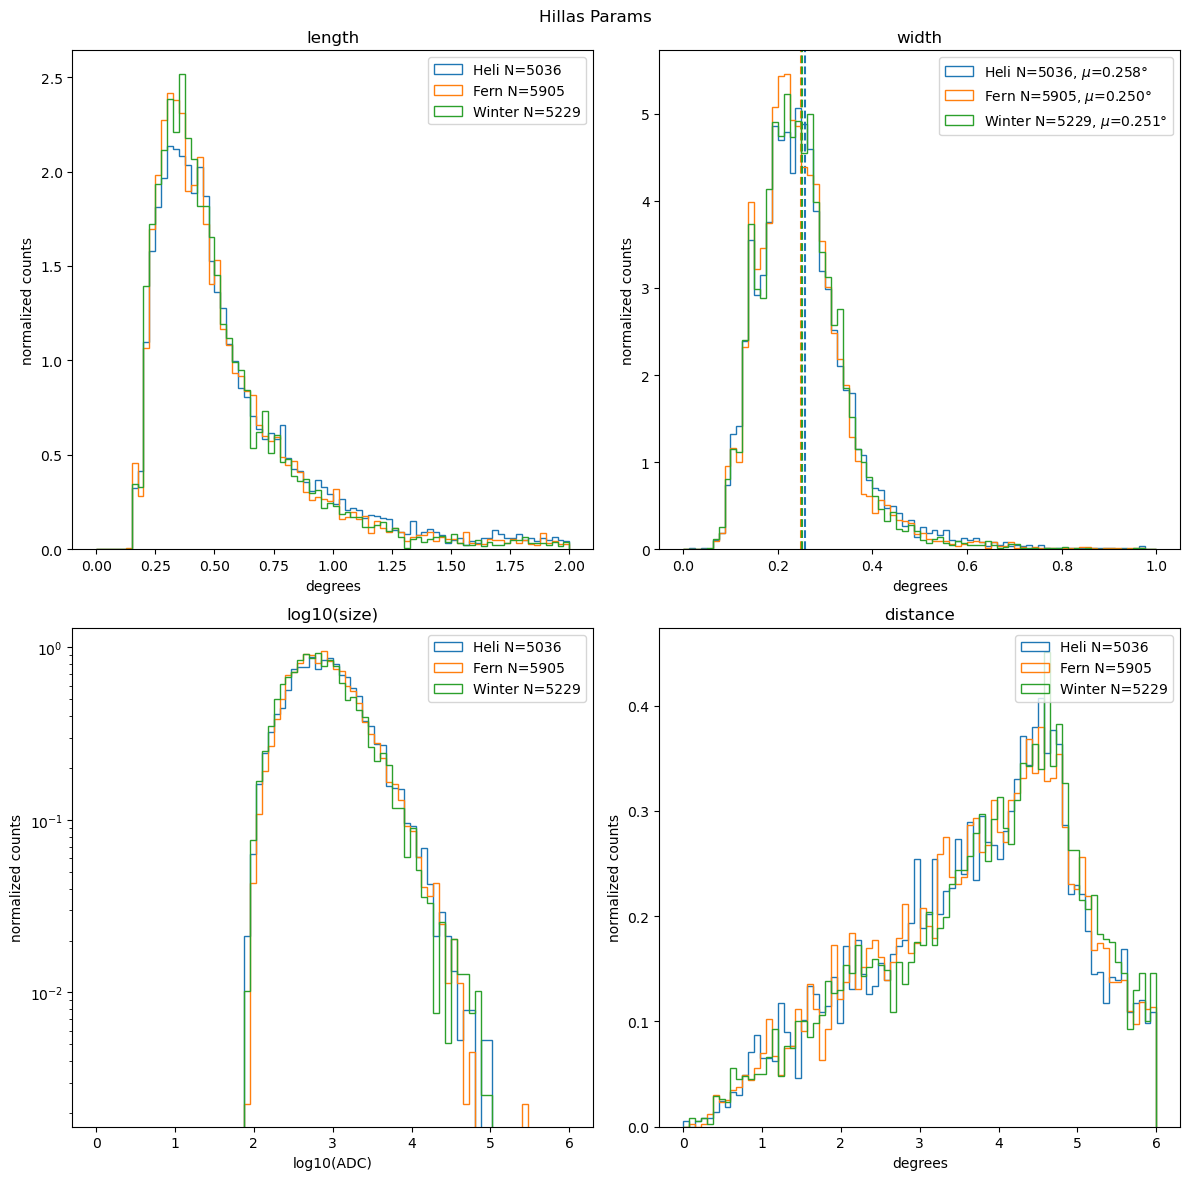

In [12]:
fig, axs = plt.subplots(2,2,figsize=(12,12))
axs=axs.flatten()
fig.suptitle("Hillas Params")

axs[0].set_title('length')
axs[0].set_xlabel('degrees')
axs[0].set_ylabel('normalized counts')

axs[1].set_title('width')
axs[1].set_xlabel('degrees')
axs[1].set_ylabel('normalized counts')

axs[2].set_title('log10(size)')
axs[2].set_yscale('log')
axs[2].set_xlabel('log10(ADC)')
axs[2].set_ylabel('normalized counts')

axs[3].set_title('distance')
axs[3].set_xlabel('degrees')
axs[3].set_ylabel('normalized counts')

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, (name, df) in enumerate(telescope_dfs.items()):
    color = colors[i % len(colors)]
    label = f"{name} N={len(df)}"
    width_mean = df.width.mean()
    width_label = f"{label}, $\mu$={width_mean:.3f}°"
    axs[0].hist(df.length, bins=80, range=(0,2), histtype='step', density=True, label=label, color=color)
    axs[1].hist(df.width, bins=80, range=(0,1), histtype='step', density=True, label=width_label, color=color)
    axs[1].axvline(width_mean, color=color, linestyle='--', linewidth=1.5)
    axs[2].hist(np.log10(df['size']), bins=80, range=(0,6), histtype='step', density=True, label=label, color=color)
    axs[3].hist(df.distance, bins=80, range=(0,6), histtype='step', density=True, label=label, color=color)

for ax in axs:
    ax.legend(loc='upper right')

plt.tight_layout()

# Some Images

In [13]:
telescope_images.keys()

dict_keys(['Heli', 'Fern', 'Winter'])

In [14]:
telescope_dfs['Heli'].describe()

,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
count,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5036.000000,5.036000e+03
mean,21.289515,1822.934949,-0.007010,-0.307222,1.395635,1.412354,-0.085024,0.660102,0.257531,2.356299,3.761022,43.550164,187.141390,4695.651112,1.783584e+09
std,19.516143,4364.942051,2.811250,2.790149,4.032799,4.040210,2.814216,0.595990,0.115275,1.533436,1.334130,26.066137,100.969228,2768.070548,1.132157e+03
min,4.000000,80.502250,-4.624145,-4.635282,0.016193,0.014019,-49.116689,0.151961,0.018921,0.001769,0.045715,0.028800,0.007229,0.000000,1.783582e+09
25%,9.000000,382.390917,-2.436200,-2.729487,0.221872,0.211877,-0.115387,0.338030,0.188751,1.014586,2.864882,20.312014,101.695730,2330.500000,1.783583e+09
50%,16.000000,786.431701,-0.298687,-0.650767,0.422536,0.403985,0.006191,0.468882,0.242321,2.189706,3.937553,43.678330,194.568078,4589.000000,1.783584e+09
75%,26.000000,1660.482270,2.453774,2.054258,0.948021,0.903992,0.139992,0.731683,0.301087,3.606449,4.702833,65.584554,269.456814,7041.500000,1.783585e+09
max,320.000000,103129.641352,4.942860,4.912687,64.919780,60.576735,48.684750,5.627140,2.014884,6.443656,6.684197,89.992039,359.987368,9748.000000,1.783586e+09


Number of events for telescope 1: 5036
Number of events for telescope 2: 5905
Number of coincident events within 0.001s: 2255 ( ~44.8% of all telescope 1 events and ~38.2% of all telescope 2 events.)
Number of events for telescope 1: 5036
Number of events for telescope 2: 5229
Number of coincident events within 0.001s: 1595 ( ~31.7% of all telescope 1 events and ~30.5% of all telescope 2 events.)
Number of events for telescope 1: 5905
Number of events for telescope 2: 5229
Number of coincident events within 0.001s: 1932 ( ~32.7% of all telescope 1 events and ~36.9% of all telescope 2 events.)
Coincidence pool: 3400 events with >=2 telescopes (1167 with all 3, 2233 with exactly 2)


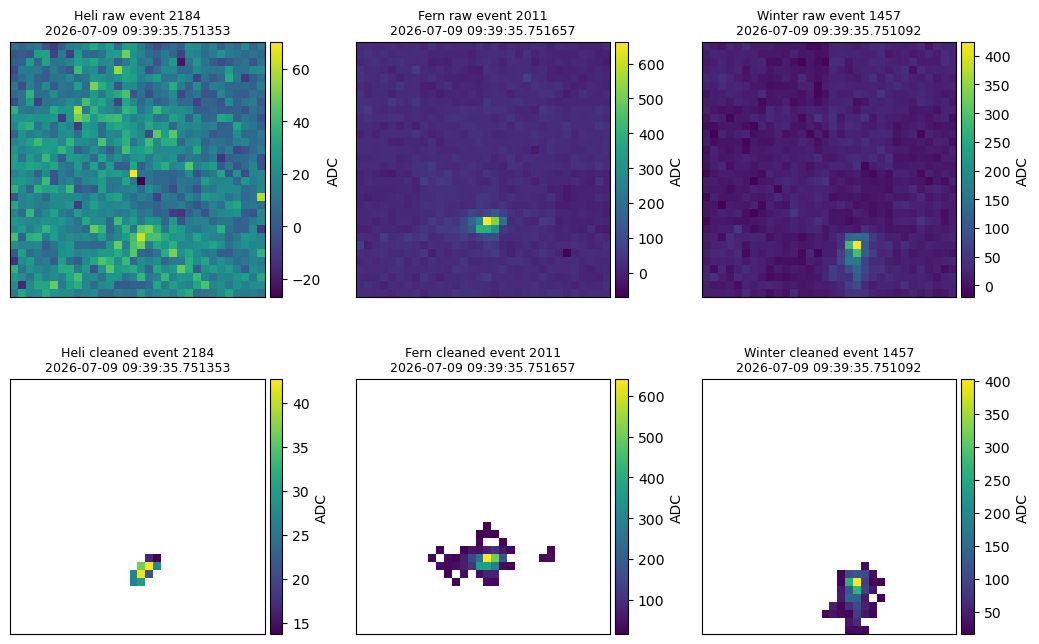

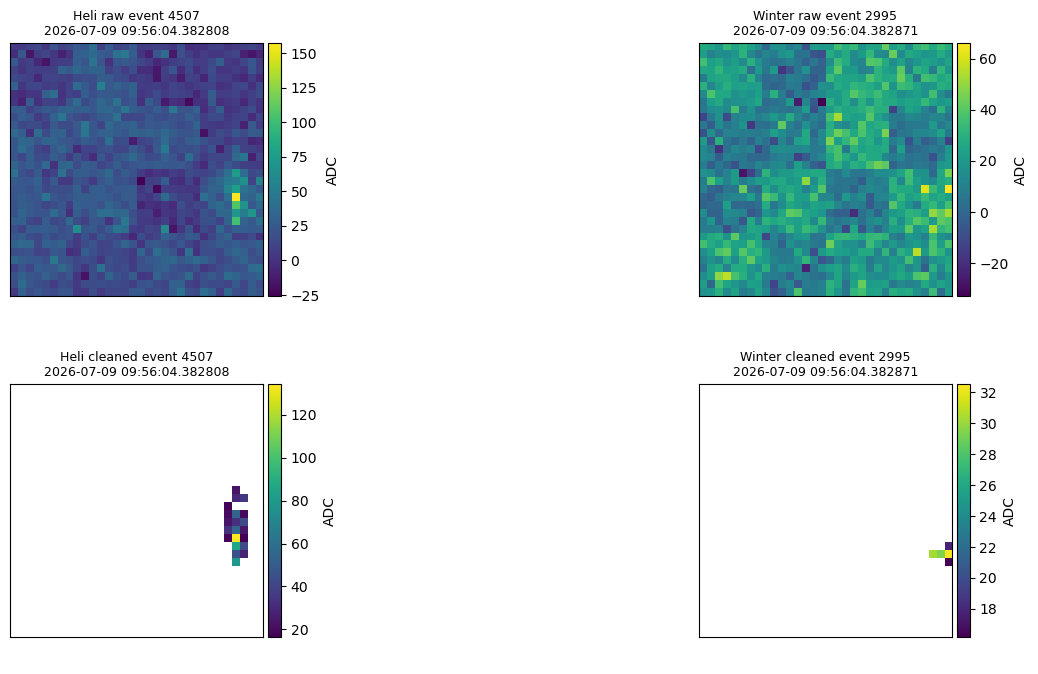

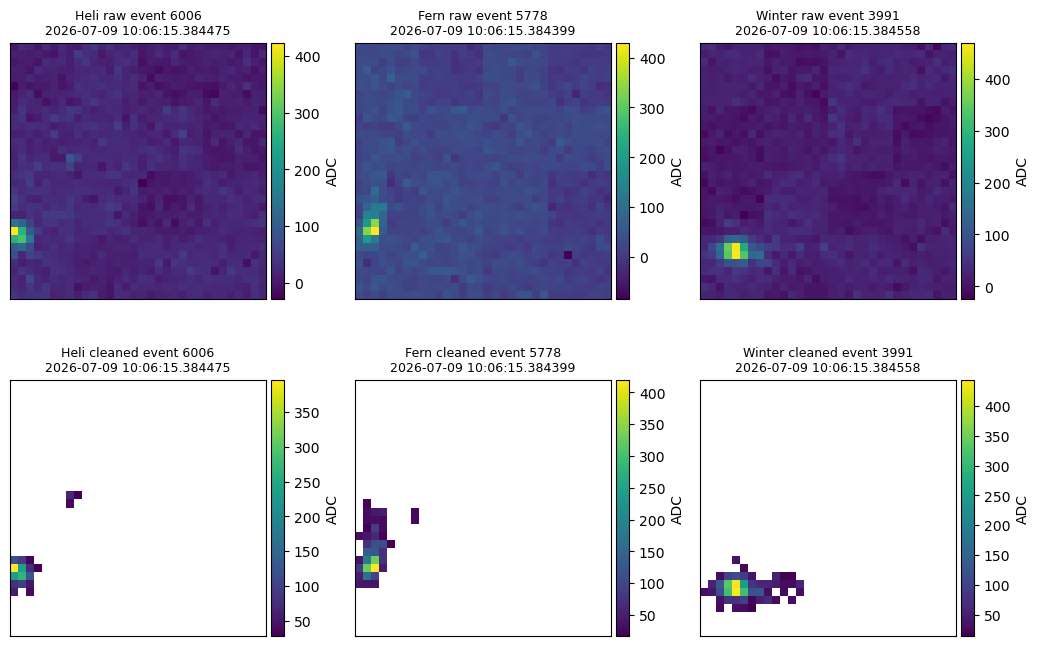

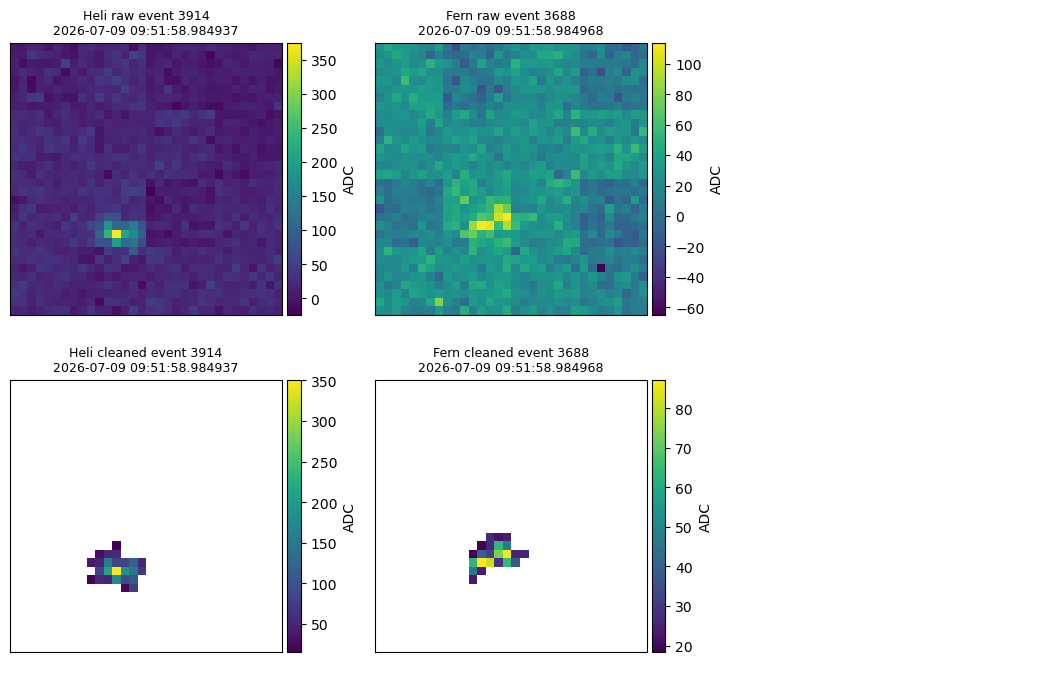

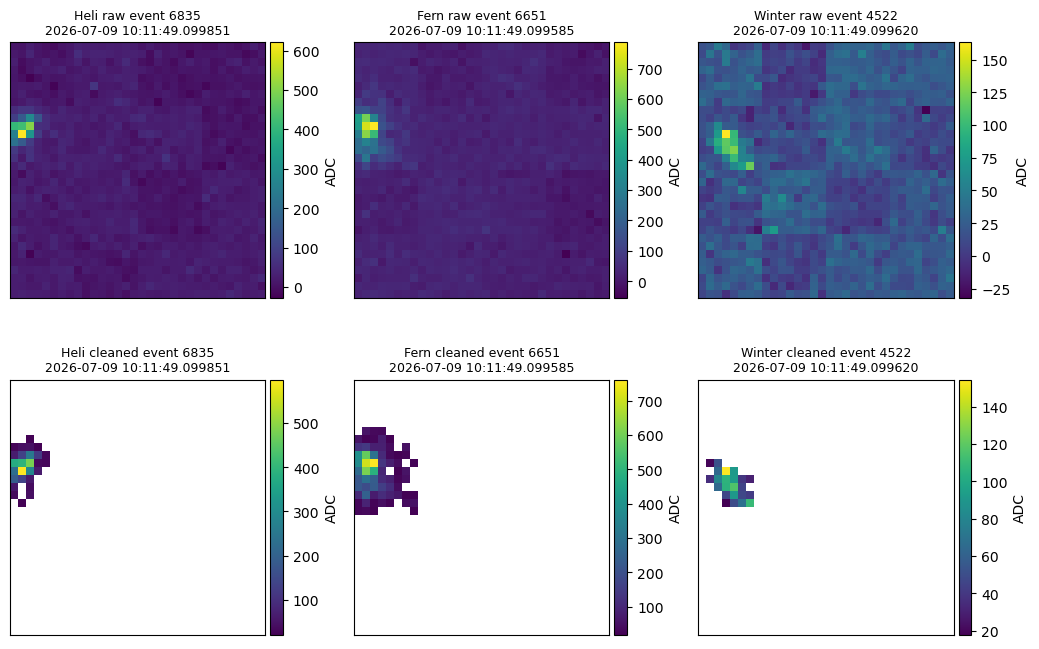

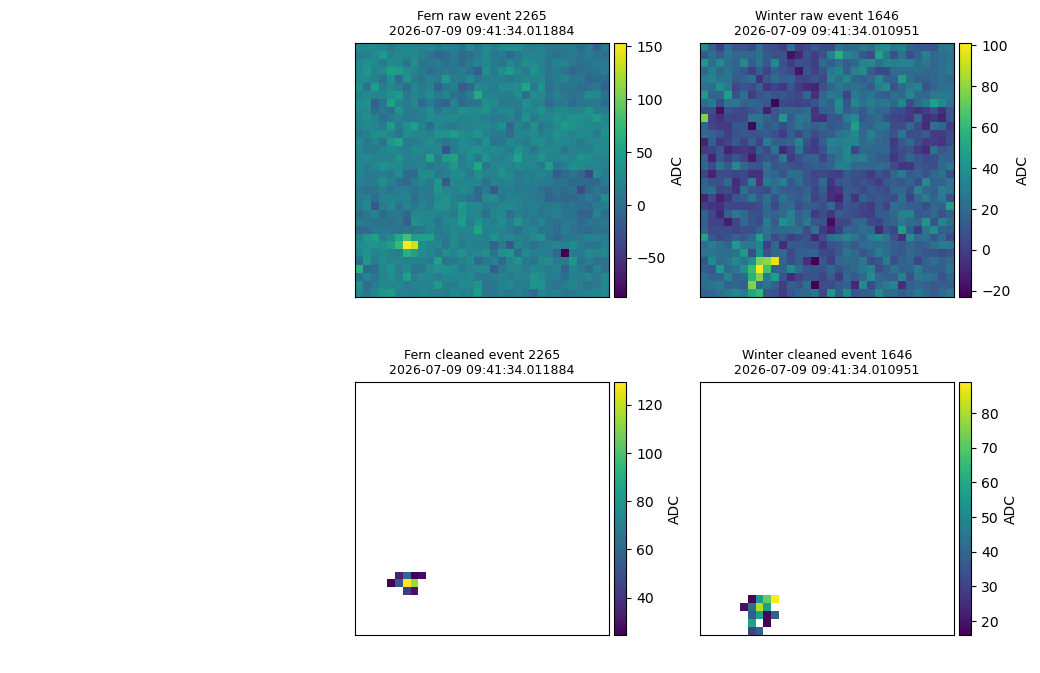

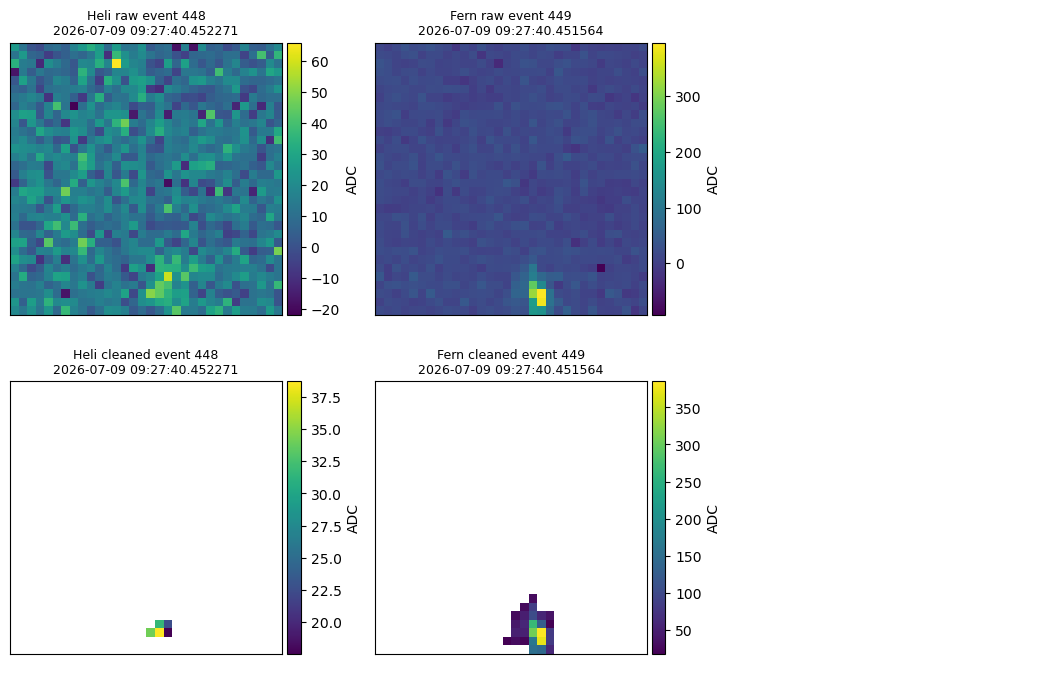

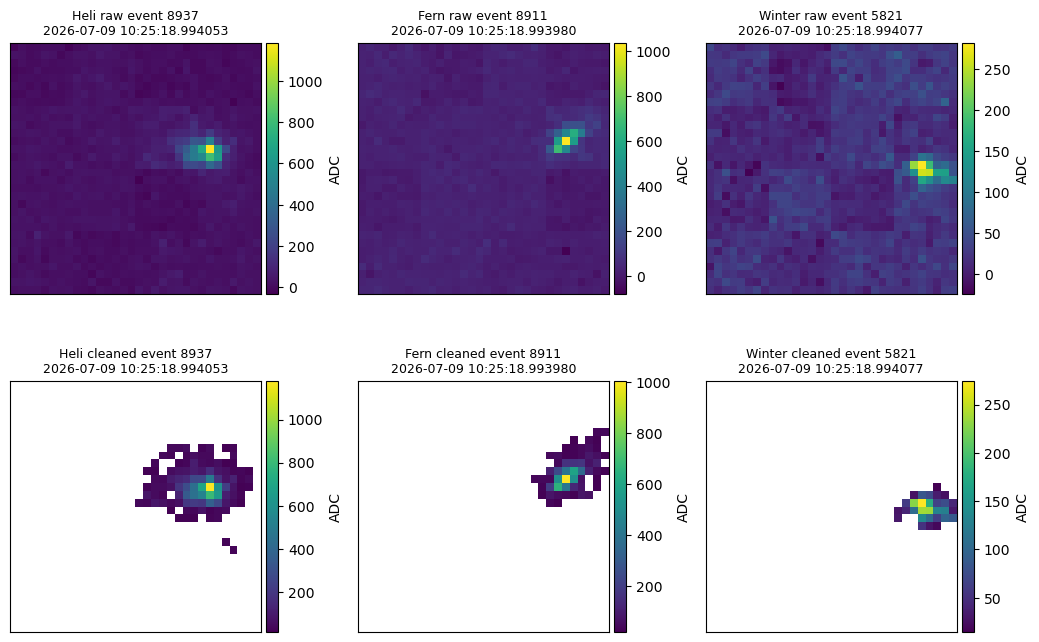

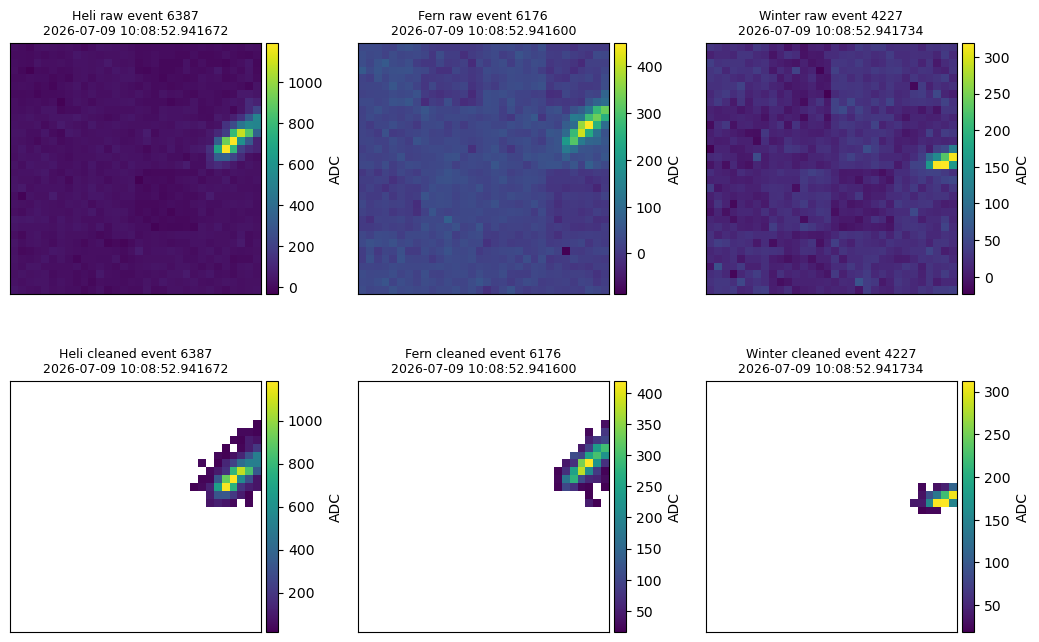

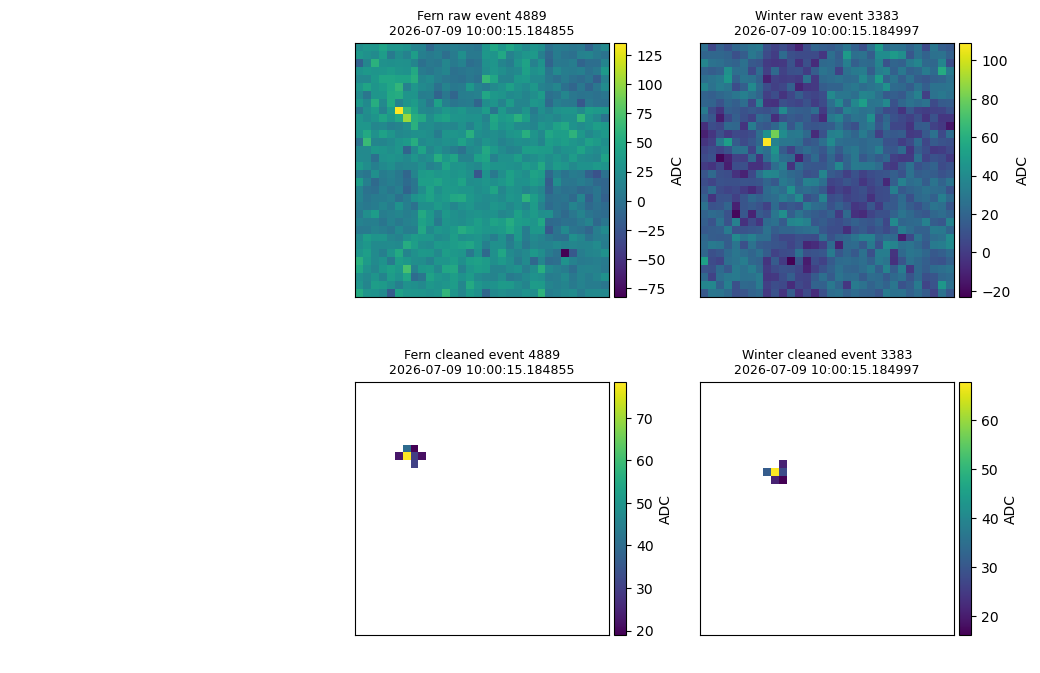

In [15]:
# Find coincident events using coincidences.match_coinc on every telescope pair, then union
# events that share a match into groups. A group is a coincidence seen by however many telescopes
# ended up linked together (2 or 3) -- no separate "exactly 2" / "exactly 3" bookkeeping needed.
from itertools import combinations

names = ['Heli', 'Fern', 'Winter']
timestamps_arr = {name: telescope_dfs[name]['Timestamp'].values for name in names}
event_idx_arr = {name: telescope_dfs[name]['Event'].values for name in names}

parent = {}


def find(node):
    while parent[node] != node:
        parent[node] = parent[parent[node]]
        node = parent[node]
    return node


def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb


for name in names:
    for idx in event_idx_arr[name]:
        parent[(name, idx)] = (name, idx)

node_time = {}
window = 0.001
for a, b in combinations(names, 2):
    t1, i1, t2, i2 = coincidences.match_coinc(timestamps_arr[a], event_idx_arr[a], timestamps_arr[b], event_idx_arr[b], window=window)
    for ta, ia, tb, ib in zip(t1, i1, t2, i2):
        node_a, node_b = (a, ia), (b, ib)
        node_time[node_a] = ta
        node_time[node_b] = tb
        union(node_a, node_b)

# Group matched nodes by root; keep only groups spanning >= 2 telescopes
groups = {}
for node in node_time:
    groups.setdefault(find(node), []).append(node)

coincidence_pool = []
for nodes in groups.values():
    tel_set = {n[0] for n in nodes}
    if len(tel_set) < 2:
        continue
    nodes = sorted(nodes, key=lambda n: names.index(n[0]))
    coincidence_pool.append(([n[0] for n in nodes], [n[1] for n in nodes], [node_time[n] for n in nodes]))

n_triples = sum(1 for g in coincidence_pool if len(g[0]) == 3)
print(f"Coincidence pool: {len(coincidence_pool)} events with >=2 telescopes "
      f"({n_triples} with all 3, {len(coincidence_pool) - n_triples} with exactly 2)")


def plot_event(tel_names, event_idx, event_time):
    """One figure per coincident event, always laid out as 2 rows (raw, clean) x len(names)
    columns (one per telescope): telescopes not part of this coincidence get a blank (but
    bordered) column, so 2-tel and 3-tel events are directly comparable at a glance. Each image
    is scaled to its own min/max (no shared color scale)."""
    raw_imgs = [telescope_images_raw[name][idx].reshape(32, 32) for name, idx in zip(tel_names, event_idx)]
    clean_imgs = [telescope_images[name][idx].reshape(32, 32) for name, idx in zip(tel_names, event_idx)]

    fig, axs = plt.subplots(2, len(names), figsize=(3.5 * len(names), 7), squeeze=False)
    # fig.suptitle(f"{'+'.join(tel_names)} coincidence")

    for col, name in enumerate(names):
        if name not in tel_names:
            for ax in (axs[0, col], axs[1, col]):
                ax.axis("off")
            continue

        i = tel_names.index(name)
        idx = event_idx[i]
        ts_str = datetime.fromtimestamp(event_time[i]).strftime('%Y-%m-%d %H:%M:%S.%f')
        for row, (label, img) in enumerate([("raw", raw_imgs[i]), ("cleaned", clean_imgs[i])]):
            ax = axs[row, col]
            im = ax.imshow(img, aspect="equal", origin="lower")
            colorbar(im, "ADC")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"{name} {label} event {idx}\n{ts_str}", fontsize=9)

    plt.tight_layout()
    return fig


n_sample = min(10, len(coincidence_pool))
rng = np.random.default_rng()
sample = rng.choice(len(coincidence_pool), size=n_sample, replace=False)

for i in sample:
    plot_event(*coincidence_pool[i])